# Dịch Máy Tự Động English-French với Mô Hình Encoder-Decoder LSTM

**Đồ án:** Dịch máy từ tiếng Anh sang tiếng Pháp sử dụng LSTM

**Mục tiêu:** Xây dựng từ đầu mô hình Encoder-Decoder LSTM cho bài toán dịch máy

## 1. Cài đặt thư viện

In [1]:
!pip install spacy torch torchtext
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 439.4 kB/s eta 0:00:28
     - ------------------------------------- 0.5/12.8 MB 439.4 kB/s eta 0:00:28
     - ------------------------------------- 0.5/12.8 MB 439.4 kB/s eta 0:00:28
     - ------------------------------------- 0.5/12.8 MB 439.4 kB/s eta 0:00:28
     -- ------------------------------------ 0.8/12.8 MB 381.4 kB/s eta 0:00:32
     -- ------------------------------------ 0.8/12.8 MB 381.4 kB/s eta 0:00:32
     --- ----------------------------------- 1.0/12.8 MB 417.7 kB/s eta 0:00:29
     ---


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
      --------------------------------------- 0.3/16.3 MB ? eta -:--:--
     ----- ---------------------------------- 2.1/16.3 MB 7.1 MB/s eta 0:00:02
     ------- -------------------------------- 3.1/16.3 MB 6.6 MB/s eta 0:00:02
     --------- ------------------------------ 3.9/16.3 MB 6.1 MB/s eta 0:00:03
     ----------- ---------------------------- 4.7/16.3 MB 5.1 MB/s eta 0:00:03
     ------------ --------------------------- 5.2/16.3 MB 4.5 MB/s eta 0:00:03
     ------------- -------------------------- 5.5/16.3 MB 4.0 MB/s eta 0:00:03
     ------------- -------------------------- 5.5/16.3 MB 4.0 MB/s eta 0:00:03
     -------------- ------------------------- 5.8/16.3 MB 3.4 MB/s eta 0:00:04
     -------------- ------------------------- 5.8/16.3 MB 3.4 MB/s eta 0:00:04
     -------------- ------------------------- 6.0/16.3 MB 2.8 MB/s eta 0:00:04
     -------------- ------------------------- 6.0/16.3 MB 2.8 MB/s


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import thư viện

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import spacy
import numpy as np
import random
import math
import time
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from collections import Counter
from functools import partial
import matplotlib.pyplot as plt

# Đặt seed để kết quả có thể tái tạo được
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Force sử dụng CPU
device = torch.device('cpu')
print(f"Device: {device}")

Device: cpu


## 3. Tokenization

In [3]:
# Load mô hình spacy cho tiếng Anh và tiếng Pháp
spacy_en = spacy.load('en_core_web_sm')
spacy_fr = spacy.load('fr_core_news_sm')

def tokenize_en(text):
    """Hàm tách từ cho tiếng Anh, chuyển về chữ thường"""
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

def tokenize_fr(text):
    """Hàm tách từ cho tiếng Pháp, chuyển về chữ thường"""
    return [tok.text.lower() for tok in spacy_fr.tokenizer(text)]

## 4. Vocabulary Class

In [4]:
class Vocabulary:
    """Class quản lý từ điển (vocabulary) để chuyển đổi giữa tokens và indices"""
    
    def __init__(self, max_size=10000):
        self.token2idx = {}
        self.idx2token = {}
        self.max_size = max_size
        
        # Các token đặc biệt
        self.PAD_TOKEN = '<pad>'
        self.UNK_TOKEN = '<unk>'
        self.SOS_TOKEN = '<sos>'
        self.EOS_TOKEN = '<eos>'
        
        self.PAD_IDX = 0
        self.UNK_IDX = 1
        self.SOS_IDX = 2
        self.EOS_IDX = 3
        
        # Khởi tạo với các token đặc biệt
        self.token2idx = {
            self.PAD_TOKEN: self.PAD_IDX,
            self.UNK_TOKEN: self.UNK_IDX,
            self.SOS_TOKEN: self.SOS_IDX,
            self.EOS_TOKEN: self.EOS_IDX
        }
        self.idx2token = {v: k for k, v in self.token2idx.items()}
    
    def build_vocab(self, tokenized_sentences):
        """Xây dựng vocabulary từ các câu đã tokenize"""
        counter = Counter()
        for tokens in tokenized_sentences:
            counter.update(tokens)
        
        # Lấy các token phổ biến nhất (trừ các token đặc biệt)
        most_common = counter.most_common(self.max_size - 4)
        
        # Thêm vào vocabulary
        for token, _ in most_common:
            if token not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[token] = idx
                self.idx2token[idx] = token
        
        print(f'Kích thước vocabulary: {len(self.token2idx)}')
    
    def encode(self, tokens):
        """Chuyển đổi tokens thành indices"""
        return [self.token2idx.get(token, self.UNK_IDX) for token in tokens]
    
    def decode(self, indices):
        """Chuyển đổi indices thành tokens"""
        return [self.idx2token.get(idx, self.UNK_TOKEN) for idx in indices]
    
    def __len__(self):
        return len(self.token2idx)


## 5. Dataset Class

In [5]:
class TranslationDataset(Dataset):
    """Custom Dataset cho các cặp câu dịch"""
    
    def __init__(self, data, src_vocab, trg_vocab, src_tokenizer, trg_tokenizer, max_len=50):
        self.data = data
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        src_text, trg_text = self.data[idx]
        
        # Tokenize
        src_tokens = self.src_tokenizer(src_text)
        trg_tokens = self.trg_tokenizer(trg_text)
        
        # Giới hạn độ dài
        src_tokens = src_tokens[:self.max_len]
        trg_tokens = trg_tokens[:self.max_len]
        
        # Thêm <sos> và <eos> tokens
        src_tokens = [self.src_vocab.SOS_TOKEN] + src_tokens + [self.src_vocab.EOS_TOKEN]
        trg_tokens = [self.trg_vocab.SOS_TOKEN] + trg_tokens + [self.trg_vocab.EOS_TOKEN]
        
        # Chuyển thành indices
        src_indices = self.src_vocab.encode(src_tokens)
        trg_indices = self.trg_vocab.encode(trg_tokens)
        
        return torch.tensor(src_indices), torch.tensor(trg_indices)


## 6. Collate Function (với pack_padded_sequence)

In [ ]:
def collate_fn(batch):
    """
    Hàm collate tùy chỉnh để padding và packing:
    - Sắp xếp batch theo độ dài giảm dần 
    - Padding các câu về cùng độ dài
    """
    # Tách source và target
    src_batch, trg_batch = zip(*batch)
    
    # Lấy độ dài
    src_lengths = torch.tensor([len(s) for s in src_batch])
    trg_lengths = torch.tensor([len(t) for t in trg_batch])
    
    # Sắp xếp theo độ dài source (giảm dần) để pack_padded_sequence
    src_lengths, sort_idx = src_lengths.sort(descending=True)
    src_batch = [src_batch[i] for i in sort_idx]
    trg_batch = [trg_batch[i] for i in sort_idx]
    trg_lengths = trg_lengths[sort_idx]
    
    # Padding sequences - format [seq_len, batch_size]
    src_padded = pad_sequence(src_batch, batch_first=False, padding_value=0)
    trg_padded = pad_sequence(trg_batch, batch_first=False, padding_value=0)
    
    return src_padded, trg_padded, src_lengths, trg_lengths

## 7. Encoder

In [7]:
class Encoder(nn.Module):
    """Encoder: Mã hóa câu nguồn thành context vector"""
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        
        # Lớp embedding chuyển index thành vector
        self.embedding = nn.Embedding(input_dim, emb_dim)
        # LSTM để xử lý chuỗi
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src, src_len):
        # src: [src_len, batch_size]
        # src_len: [batch_size]
        
        # Embedding và dropout
        embedded = self.dropout(self.embedding(src))  # [src_len, batch_size, emb_dim]
        
        # Pack padded sequence để bỏ qua các vị trí padding
        packed_embedded = pack_padded_sequence(embedded, src_len.cpu(), enforce_sorted=True)
        
        # Chạy qua LSTM
        packed_outputs, (hidden, cell) = self.rnn(packed_embedded)
        # hidden: [n_layers, batch_size, hid_dim] - context vector
        # cell: [n_layers, batch_size, hid_dim] - cell state
        
        return hidden, cell

## 8. Decoder

In [8]:
class Decoder(nn.Module):
    """Decoder: Giải mã context vector thành câu đích"""
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.hid_dim = hid_dim
        self.n_layers = n_layers
        
        # Lớp embedding cho câu đích
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # LSTM để sinh từng từ
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout)
        # Lớp fully connected để dự đoán từ tiếp theo
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, input, hidden, cell):
        # input: [batch_size] - từ hiện tại
        # hidden: [n_layers, batch_size, hid_dim]
        # cell: [n_layers, batch_size, hid_dim]
        
        # Thêm chiều sequence length
        input = input.unsqueeze(0)  # [1, batch_size]
        
        # Embedding và dropout
        embedded = self.dropout(self.embedding(input))  # [1, batch_size, emb_dim]
        
        # Chạy qua LSTM với context từ encoder
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        # output: [1, batch_size, hid_dim]
        
        # Dự đoán từ tiếp theo
        prediction = self.fc_out(output.squeeze(0))  # [batch_size, output_dim]
        
        return prediction, hidden, cell

## 9. Seq2Seq Model

In [9]:
class Seq2Seq(nn.Module):
    """Mô hình Seq2Seq kết hợp Encoder và Decoder"""
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        
        # Kiểm tra Encoder và Decoder phải có cùng hidden_dim và n_layers
        assert encoder.hid_dim == decoder.hid_dim
        assert encoder.n_layers == decoder.n_layers
        
    def forward(self, src, src_len, trg, teacher_forcing_ratio=0.5):
        # src: [src_len, batch_size]
        # trg: [trg_len, batch_size]
        # teacher_forcing_ratio: xác suất sử dụng từ đúng thay vì từ dự đoán
        
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        
        # Tensor lưu kết quả dự đoán
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        
        # Encoder mã hóa câu nguồn
        hidden, cell = self.encoder(src, src_len)
        
        # Từ đầu tiên là <sos>
        input = trg[0, :]
        
        # Decoder sinh từng từ
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            
            outputs[t] = output
            
            # Teacher Forcing: 50% dùng từ đúng, 50% dùng từ dự đoán
            best_guess = output.argmax(1)
            input = trg[t] if random.random() < teacher_forcing_ratio else best_guess
            
        return outputs

## 10. Load dữ liệu và xây dựng Vocabulary

In [11]:
# ========== ĐỌC DỮ LIỆU ==========
def load_data(src_file, trg_file):
    """Đọc file dữ liệu song ng English-French"""
    with open(src_file, 'r', encoding='utf-8') as f:
        src_sentences = [line.strip() for line in f]
    
    with open(trg_file, 'r', encoding='utf-8') as f:
        trg_sentences = [line.strip() for line in f]
    
    return list(zip(src_sentences, trg_sentences))

# Đọc dữ liệu train, validation và test
train_data = load_data('../dataset/train.en', '../dataset/train.fr')
val_data = load_data('../dataset/val.en', '../dataset/val.fr')
test_data = load_data('../dataset/test.en', '../dataset/test.fr')

print(f'Tập train: {len(train_data)} cặp câu')
print(f'Tập validation: {len(val_data)} cặp câu')
print(f'Tập test: {len(test_data)} cặp câu')
print(f'\nVí dụ:')
print(f'EN: {train_data[0][0]}')
print(f'FR: {train_data[0][1]}')

# ========== XÂY DỰNG VOCABULARY ==========
print('\nXây dựng vocabulary tiếng Anh...')
SRC_vocab = Vocabulary(max_size=10000)
src_tokenized = [tokenize_en(src) for src, trg in train_data]
SRC_vocab.build_vocab(src_tokenized)

print('\nXây dựng vocabulary tiếng Pháp...')
TRG_vocab = Vocabulary(max_size=10000)
trg_tokenized = [tokenize_fr(trg) for src, trg in train_data]
TRG_vocab.build_vocab(trg_tokenized)

Tập train: 29000 cặp câu
Tập validation: 1014 cặp câu
Tập test: 1000 cặp câu

Ví dụ:
EN: Two young, White males are outside near many bushes.
FR: Deux jeunes hommes blancs sont dehors près de buissons.

Xây dựng vocabulary tiếng Anh...
Kích thước vocabulary: 9797

Xây dựng vocabulary tiếng Pháp...
Kích thước vocabulary: 10000


## 11. Tạo DataLoader

In [12]:
# Tạo datasets
train_dataset = TranslationDataset(train_data, SRC_vocab, TRG_vocab, tokenize_en, tokenize_fr)
valid_dataset = TranslationDataset(val_data, SRC_vocab, TRG_vocab, tokenize_en, tokenize_fr)
test_dataset = TranslationDataset(test_data, SRC_vocab, TRG_vocab, tokenize_en, tokenize_fr)

# Tạo dataloaders
BATCH_SIZE = 128  


train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                           collate_fn=collate_fn, num_workers=0)
valid_iterator = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                           collate_fn=collate_fn, num_workers=0)
test_iterator = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                           collate_fn=collate_fn, num_workers=0)

print(f'Số batch train: {len(train_iterator)}')
print(f'Số batch validation: {len(valid_iterator)}')
print(f'Số batch test: {len(test_iterator)}')

Số batch train: 227
Số batch validation: 8
Số batch test: 8


## 12. Khởi tạo model

In [13]:
# ========== THIẾT LẬP CÁC THAM SỐ MÔ HÌNH ==========
INPUT_DIM = len(SRC_vocab)      # Kích thước vocabulary nguồn
OUTPUT_DIM = len(TRG_vocab)     # Kích thước vocabulary đích
ENC_EMB_DIM = 256               # Số chiều embedding cho encoder
DEC_EMB_DIM = 256               # Số chiều embedding cho decoder
HID_DIM = 512                   # Số chiều hidden state (theo recommended parameters)
N_LAYERS = 2                    # Số lớp LSTM
ENC_DROPOUT = 0.5               # Dropout cho encoder
DEC_DROPOUT = 0.5               # Dropout cho decoder

# Khởi tạo Encoder, Decoder và Seq2Seq model
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

# Khởi tạo trọng số ngẫu nhiên trong khoảng [-0.08, 0.08]
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

model.apply(init_weights)

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model parameters: 17,554,448


## 13. Optimizer và Loss

In [14]:
# ========== OPTIMIZER VÀ LOSS FUNCTION ==========
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  # Optimizer Adam
TRG_PAD_IDX = TRG_vocab.PAD_IDX
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)  # Bỏ qua loss của padding token

## 14. Training & Evaluation Functions

In [15]:
def train(model, iterator, optimizer, criterion, clip):
    """Hàm huấn luyện model cho 1 epoch"""
    model.train()  # Chuyển sang chế độ training
    epoch_loss = 0
    
    for src, trg, src_len, trg_len in iterator:
        src, trg = src.to(device), trg.to(device)
        
        # Reset gradient
        optimizer.zero_grad()
        
        # Forward pass
        output = model(src, src_len, trg)
        
        # Reshape output và target để tính loss
        # Bỏ <sos> token (vị trí đầu tiên)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)  # [(trg_len - 1) * batch_size, output_dim]
        trg = trg[1:].view(-1)                     # [(trg_len - 1) * batch_size]
        
        # Tính loss
        loss = criterion(output, trg)
        
        # Backward pass
        loss.backward()
        
        # Clip gradient để tránh exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        # Cập nhật trọng số
        optimizer.step()
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    """Hàm đánh giá model trên validation set"""
    model.eval()  # Chuyển sang chế độ evaluation
    epoch_loss = 0
    
    with torch.no_grad():  # Không tính gradient
        for src, trg, src_len, trg_len in iterator:
            src, trg = src.to(device), trg.to(device)

            # Forward pass, không dùng teacher forcing (ratio=0)
            output = model(src, src_len, trg, teacher_forcing_ratio=0)
            
            # Reshape để tính loss
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

## 15. Training Loop

In [16]:
# Thiết lập tham số training
N_EPOCHS = 10  # Số epoch tối đa
CLIP = 1  # Gradient clipping để tránh exploding gradient
best_valid_loss = float('inf')  # Lưu loss nhỏ nhất trên validation set
early_stop_cnt = 0  # Đếm số epoch không cải thiện
PATIENCE = 3  # Dừng sớm nếu không cải thiện sau 3 epoch

# Lưu loss để vẽ biểu đồ
train_losses = []
valid_losses = []

# Vòng lặp training

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Train model trên tập train
    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    # Đánh giá model trên tập validation
    valid_loss = evaluate(model, valid_iterator, criterion)
    
    end_time = time.time()
    
    # Lưu loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    
    # In kết quả epoch
    print(f'Epoch: {epoch+1:02} | Time: {end_time - start_time:.2f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')
    
    # Lưu model tốt nhất
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print('\t>>> Saved best model!')
        early_stop_cnt = 0  # Reset bộ đếm
    else:
        early_stop_cnt += 1  # Tăng bộ đếm nếu không cải thiện
        if early_stop_cnt >= PATIENCE:

            print("\nEarly Stopping!")  # Dừng sớm nếu đủ patience            break

Epoch: 01 | Time: 1589.18s
	Train Loss: 5.110 | Train PPL: 165.744
	 Val. Loss: 4.900 |  Val. PPL: 134.311
	>>> Saved best model!
Epoch: 02 | Time: 1442.58s
	Train Loss: 4.333 | Train PPL:  76.209
	 Val. Loss: 4.664 |  Val. PPL: 106.073
	>>> Saved best model!
Epoch: 03 | Time: 1639.30s
	Train Loss: 3.947 | Train PPL:  51.764
	 Val. Loss: 4.452 |  Val. PPL:  85.792
	>>> Saved best model!
Epoch: 04 | Time: 1537.87s
	Train Loss: 3.597 | Train PPL:  36.472
	 Val. Loss: 4.253 |  Val. PPL:  70.319
	>>> Saved best model!
Epoch: 05 | Time: 1167.77s
	Train Loss: 3.328 | Train PPL:  27.893
	 Val. Loss: 4.051 |  Val. PPL:  57.431
	>>> Saved best model!
Epoch: 06 | Time: 1098.84s
	Train Loss: 3.095 | Train PPL:  22.084
	 Val. Loss: 3.886 |  Val. PPL:  48.740
	>>> Saved best model!
Epoch: 07 | Time: 1058.37s
	Train Loss: 2.884 | Train PPL:  17.892
	 Val. Loss: 3.850 |  Val. PPL:  46.997
	>>> Saved best model!
Epoch: 08 | Time: 1203.58s
	Train Loss: 2.687 | Train PPL:  14.681
	 Val. Loss: 3.694 |  V

## 16. Vẽ biểu đồ Loss

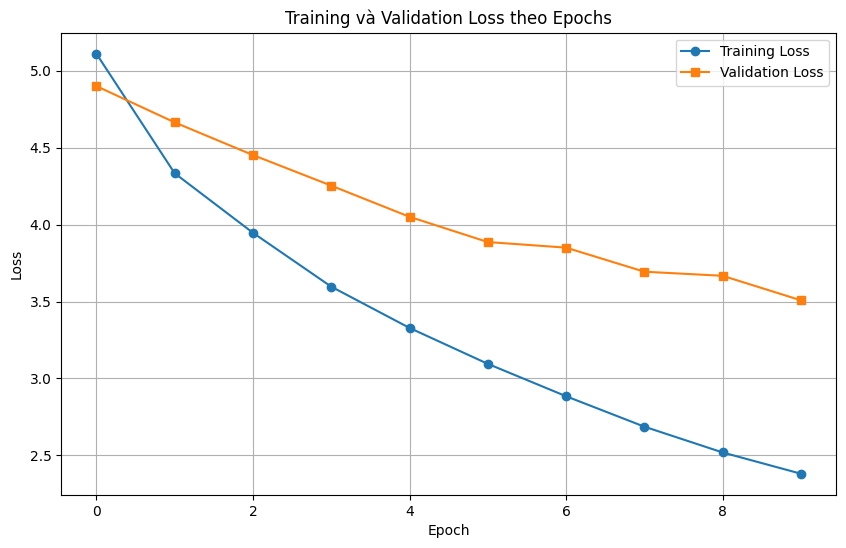

Đã lưu biểu đồ loss vào loss_chart.png


In [17]:

# Vẽ biểu đồ training và validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(valid_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training và Validation Loss theo Epochs')
plt.legend()
plt.grid(True)
plt.savefig('loss_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print('Đã lưu biểu đồ loss vào loss_chart.png')

# Lưu losses để sử dụng sau này
np.save('train_losses.npy', np.array(train_losses))
np.save('val_losses.npy', np.array(valid_losses))

## 17. Hàm translate() 

In [18]:
def translate_sentence(sentence, src_vocab, trg_vocab, src_tokenizer, model, device, max_len=50):
    """
    Hàm dịch 1 câu từ nguồn sang đích
    Args:
        sentence: Câu cần dịch (string hoặc list tokens)
        max_len: Độ dài tối đa của câu dịch
    Returns:
        List các token đã dịch
    """
    model.eval()
    
    # Tokenize câu nguồn
    if isinstance(sentence, str):
        tokens = [token.lower() for token in src_tokenizer(sentence)]
    else:
        tokens = [token.lower() for token in sentence]

    # Thêm <sos> và <eos>
    tokens = ['<sos>'] + tokens + ['<eos>']
    
    # Chuyển thành indices và tensor
    src_indexes = src_vocab.encode(tokens)
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device)  # [src_len, 1]
    
    src_len = torch.LongTensor([len(src_indexes)])
    
    # Encode câu nguồn
    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor, src_len)

    # Bắt đầu decode từ <sos>
    trg_indexes = [trg_vocab.SOS_IDX]
    
    # Sinh từng từ cho đến khi gặp <eos> hoặc đạt max_len
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        
        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)
        
        # Lấy từ có xác suất cao nhất
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        
        # Dừng nếu gặp <eos>
        if pred_token == trg_vocab.EOS_IDX:
            break
            
    # Chuyển indices thành tokens (bỏ <sos> và <eos>)
    trg_tokens = [trg_vocab.idx2token[i] for i in trg_indexes]
    
    return trg_tokens[1:-1]

def translate(sentence: str) -> str:
    """Hàm dịch theo yêu cầu đề bài - trả về chuỗi đã dịch"""
    pred_tokens = translate_sentence(sentence, SRC_vocab, TRG_vocab, tokenize_en, model, device)
    return ' '.join(pred_tokens)

## 18. Test dịch

In [19]:
# ========== LOAD MODEL TỐT NHẤT VÀ TEST DỊCH ==========
model.load_state_dict(torch.load('best_model.pth'))

test_sentences = [
    "I love programming",
    "A man is standing on a ladder",
    "Two dogs are running in the park"
]

for sent in test_sentences:
    translation = translate(sent)
    print(f"EN: {sent}")
    print(f"FR: {translation}\n")

EN: I love programming
FR: nancy <unk> .

EN: A man is standing on a ladder
FR: un homme est debout sur un banc .

EN: Two dogs are running in the park
FR: deux chiens courent dans l' herbe .



## 19. Tính BLEU Score trên Test Set

In [20]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu
import nltk
nltk.download('punkt', quiet=True)

def calculate_bleu(model, dataset, src_vocab, trg_vocab, src_tokenizer, trg_tokenizer, device, max_samples=1000):
    """
    Tính BLEU score trên dataset
    BLEU đánh giá chất lượng dịch bằng cách so sánh với câu tham chiếu
    """
    model.eval()
    references = []  # Câu tham chiếu (ground truth)
    hypotheses = []  # Câu dự đoán (model prediction)
    
    num_samples = min(len(dataset), max_samples)
    
    for i in range(num_samples):
        src_sent, trg_sent = dataset.data[i]
        
        # Tokenize câu tham chiếu và dịch câu nguồn
        trg_tokens = trg_tokenizer(trg_sent)
        pred_tokens = translate_sentence(src_sent, src_vocab, trg_vocab, src_tokenizer, model, device)
        
        references.append([trg_tokens])
        hypotheses.append(pred_tokens)
    
    # Tính BLEU score trên toàn bộ corpus
    bleu_score = corpus_bleu(references, hypotheses) * 100
    return bleu_score

# Load test dataset (dùng test_data đã có từ phần 10)
test_dataset_for_bleu = TranslationDataset(test_data, SRC_vocab, TRG_vocab, tokenize_en, tokenize_fr)

bleu_score = calculate_bleu(model, test_dataset_for_bleu, SRC_vocab, TRG_vocab, 
                             tokenize_en, tokenize_fr, device, max_samples=1000)

print(f"\nBLEU SCORE (TEST SET): {bleu_score:.2f}")


BLEU SCORE (TEST SET): 27.07


## 20. Phân tích lỗi - 5 ví dụ từ Test Set

In [21]:
# ========== PHÂN TÍCH LỖI CHI TIẾT ==========
print("\n" + "="*70)
print("PHÂN TÍCH LỖI - 5 VÍ DỤ TỪ TEST SET")
print("="*70)

# Chọn 5 ví dụ cố định từ test set
sample_indices = [0, 1, 2, 3, 4]

for idx, i in enumerate(sample_indices, 1):
    src_sent, trg_sent = test_data[i]
    
    # Dịch câu và tokenize reference đúng cách
    pred_tokens = translate_sentence(src_sent, SRC_vocab, TRG_vocab, tokenize_en, model, device)
    pred_sent = ' '.join(pred_tokens)
    
    # Tokenize reference giống như cách model đã học (lowercase)
    trg_tokens = [tok.lower() for tok in tokenize_fr(trg_sent)]
    
    # Tính BLEU score - sử dụng smoothing để tránh BLEU = 0
    from nltk.translate.bleu_score import SmoothingFunction
    smoothie = SmoothingFunction().method1
    bleu = sentence_bleu([trg_tokens], pred_tokens, smoothing_function=smoothie) * 100
    
    print(f"\n{'='*70}")
    print(f"VÍ DỤ {idx}")
    print(f"{'='*70}")
    print(f"Source (EN):    {src_sent}")
    print(f"Reference (FR): {trg_sent}")
    print(f"Prediction:     {pred_sent}")
    print(f"BLEU:           {bleu:.2f}")
    
    # Debug: In ra tokens để kiểm tra
    print(f"\nDEBUG:")
    print(f"Reference tokens: {trg_tokens[:10]}...")
    print(f"Predicted tokens: {pred_tokens[:10]}...")
    
    # Đếm số từ trùng khớp
    matched = len(set(trg_tokens) & set(pred_tokens))
    print(f"Số từ trùng khớp: {matched}/{len(set(trg_tokens))}")
    
    # ===== PHÂN TÍCH CÁC LOẠI LỖI =====
    print(f"\nPHÂN TÍCH LỖI:")
    
    # 1. Phân tích độ dài câu
    src_len = len(src_sent.split())
    ref_len = len(trg_sent.split())
    pred_len = len(pred_sent.split())
    print(f"  Độ dài: Source={src_len}, Reference={ref_len}, Prediction={pred_len}")
    
    if abs(pred_len - ref_len) > 3:
        print(f"  → Lỗi độ dài: Chênh lệch {abs(pred_len - ref_len)} từ")
    
    # 2. Kiểm tra từ OOV (Out-Of-Vocabulary)
    src_tokens = tokenize_en(src_sent)
    oov_words = [word for word in src_tokens if SRC_vocab.token2idx.get(word, SRC_vocab.UNK_IDX) == SRC_vocab.UNK_IDX]
    if oov_words:
        print(f"  → Từ OOV: {oov_words}")
        print(f"     Nguyên nhân: Từ không có trong vocabulary")
    
    # 3. So sánh tokens: từ thiếu và từ thừa
    missing = set(trg_tokens) - set(pred_tokens)
    extra = set(pred_tokens) - set(trg_tokens)
    if missing:
        print(f"  → Từ thiếu: {list(missing)[:5]}")
    if extra:
        print(f"  → Từ thừa: {list(extra)[:5]}")
    
    # 4. Phân tích nguyên nhân và đề xuất giải pháp
    print(f"\n  Nguyên nhân:")
    if matched == 0:
        print(f"    - KHÔNG CÓ TỪ NÀO TRÙNG KHỚP → Model dịch hoàn toàn sai")
        print(f"    - Có thể model chưa được train đủ hoặc quá phức tạp cho dữ liệu")
    elif matched < 3:
        print(f"    - Rất ít từ trùng khớp → Dịch sai nghiêm trọng")
    if src_len > 20:
        print(f"    - Câu dài ({src_len} từ) → Context vector bottleneck")
        print(f"      Model khó nén toàn bộ thông tin câu dài vào 1 vector")
    if oov_words:
        print(f"    - Có từ OOV → Model không học được các từ này")
        print(f"      Giải pháp: Tăng kích thước vocabulary hoặc dùng subword tokenization")
    if bleu < 30:
        print(f"    - BLEU thấp → Dịch sai cấu trúc hoặc ngữ pháp")
        print(f"    - Giải pháp chính: Thêm Attention Mechanism")
        print(f"      + Attention giúp Decoder tập trung vào từng phần của câu nguồn")
        print(f"      + Giải quyết vấn đề context vector bottleneck")




PHÂN TÍCH LỖI - 5 VÍ DỤ TỪ TEST SET

VÍ DỤ 1
Source (EN):    A man in an orange hat starring at something.
Reference (FR): Un homme avec un chapeau orange regardant quelque chose.
Prediction:     un homme avec un chapeau orange regarde quelque chose .
BLEU:           65.80

DEBUG:
Reference tokens: ['un', 'homme', 'avec', 'un', 'chapeau', 'orange', 'regardant', 'quelque', 'chose', '.']...
Predicted tokens: ['un', 'homme', 'avec', 'un', 'chapeau', 'orange', 'regarde', 'quelque', 'chose', '.']...
Số từ trùng khớp: 8/9

PHÂN TÍCH LỖI:
  Độ dài: Source=9, Reference=9, Prediction=10
  → Từ thiếu: ['regardant']
  → Từ thừa: ['regarde']

  Nguyên nhân:

VÍ DỤ 2
Source (EN):    A Boston Terrier is running on lush green grass in front of a white fence.
Reference (FR): Un terrier de Boston court sur l'herbe verdoyante devant une clôture blanche.
Prediction:     un athlète court court sur la pelouse devant un grand bleu .
BLEU:           3.83

DEBUG:
Reference tokens: ['un', 'terrier', 'de', 'bo